## Superstore Dataset - (Data Visualization)

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [2]:
df = pd.read_csv('blinkit_dataset.csv')
df.head()
df.shape

(8523, 12)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


### Handle Missing Values

In [4]:
missing_value = df.isnull().sum()
print(missing_value)

missing_percentage = (missing_value/len(df))*100
missing_percentage

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64


Item Fat Content              0.000000
Item Identifier               0.000000
Item Type                     0.000000
Outlet Establishment Year     0.000000
Outlet Identifier             0.000000
Outlet Location Type          0.000000
Outlet Size                   0.000000
Outlet Type                   0.000000
Item Visibility               0.000000
Item Weight                  17.165317
Sales                         0.000000
Rating                        0.000000
dtype: float64

In [5]:
mean_weight = df['Item Weight'].mean()
df['Item Weight'] = df['Item Weight'].fillna(mean_weight) # Filling all the missing value with mean
print(df.isnull().sum())

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64


### Handling Duplicate values

In [6]:
duplicates = df.duplicated().sum()
print('Duplicate values:', duplicates)

Duplicate values: 0


### Exploratory Data Analysis

#### Sales by Outlet Establishment Year

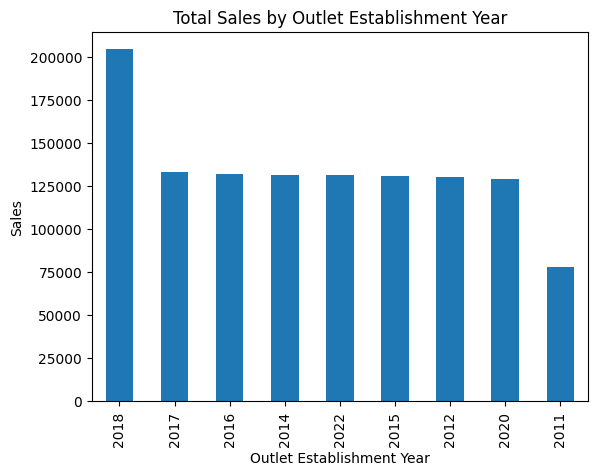

In [15]:
df.groupby('Outlet Establishment Year')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Sales')
plt.savefig('Sales by Outlet Establishment Year.png', dpi=300, bbox_inches='tight')
plt.show()

#### Sales by Outlet type


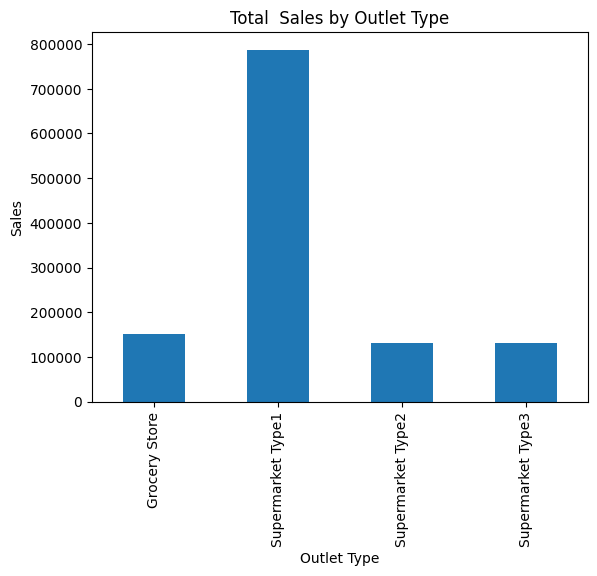

In [16]:
df.groupby('Outlet Type')['Sales'].sum().plot(kind='bar')
plt.title('Total  Sales by Outlet Type')
plt.ylabel('Sales')
plt.savefig('Sales by Outlet Type.png', dpi=300, bbox_inches='tight')
plt.show()

#### Sales by Outlet Location Type

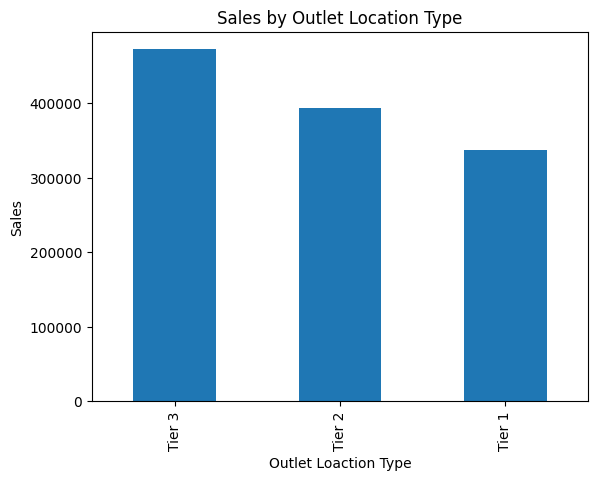

In [9]:
df.groupby('Outlet Location Type')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Sales by Outlet Location Type')
plt.xlabel('Outlet Loaction Type')
plt.ylabel('Sales')
plt.savefig('Sales by Outlet Location Type.png', dpi=300, bbox_inches='tight')
plt.show()

#### Sales by Outlet Size

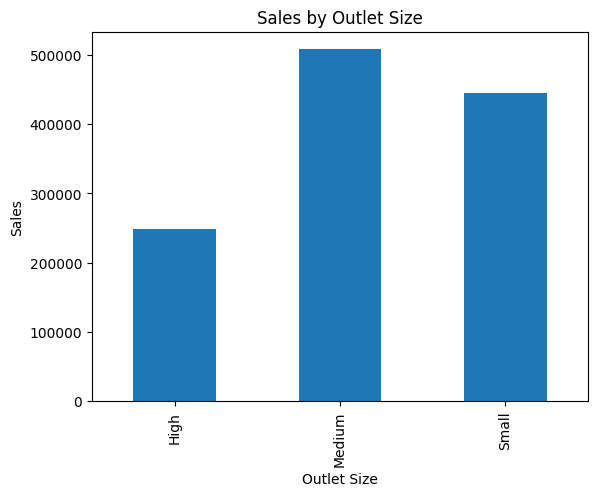

In [10]:
df.groupby('Outlet Size')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Sales')
plt.savefig('Sales by Outlet Size.png', dpi=300, bbox_inches='tight')
plt.show()

#### Sales by Item Type

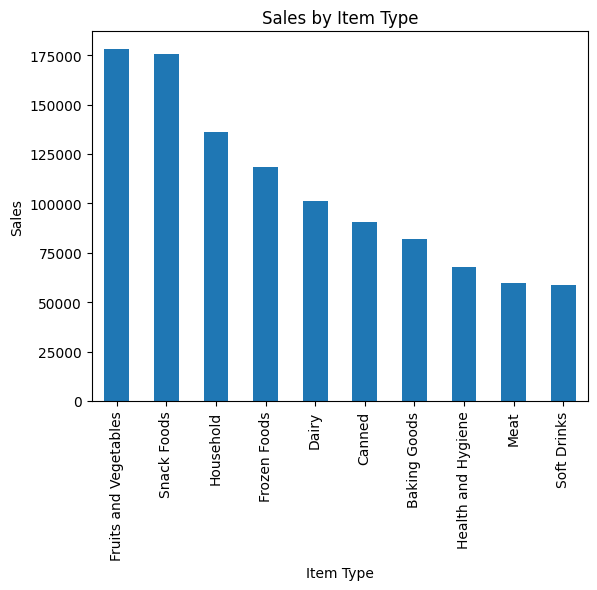

In [23]:
df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Sales')
plt.savefig('Sales by Item Type.png', dpi=300, bbox_inches='tight')
plt.show()

#### Sales by Item Fat Content

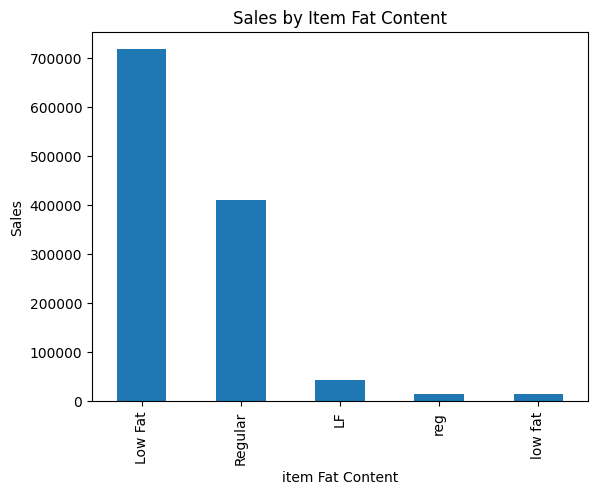

In [20]:
df.groupby('Item Fat Content')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Sales by Item Fat Content')
plt.xlabel('item Fat Content')
plt.ylabel('Sales')
plt.savefig('Sales by Item Fat Content.png', dpi=300, bbox_inches='tight')
plt.show()

#### Item Visibility vs Sales


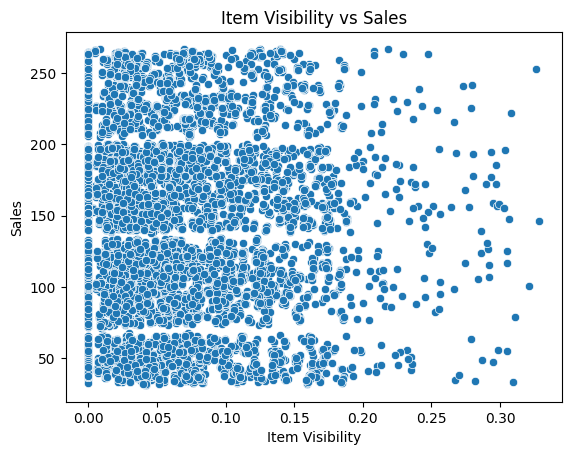

In [12]:
sns.scatterplot(x='Item Visibility', y='Sales', data=df)
plt.title('Item Visibility vs Sales')
plt.savefig('Item Visibility vs Sales.png', dpi=300, bbox_inches='tight')
plt.show()

#### Rating vs Sales

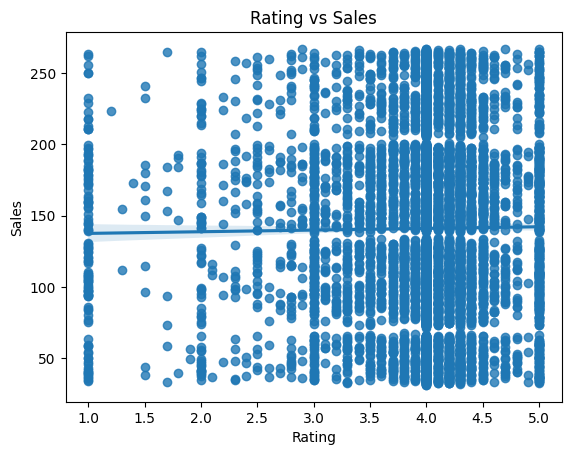

In [13]:
sns.regplot(x='Rating', y='Sales', data=df)
plt.title('Rating vs Sales')
plt.savefig('Rating vs Sales.png', dpi=300, bbox_inches='tight')
plt.show()

#### Correlation Heatmap


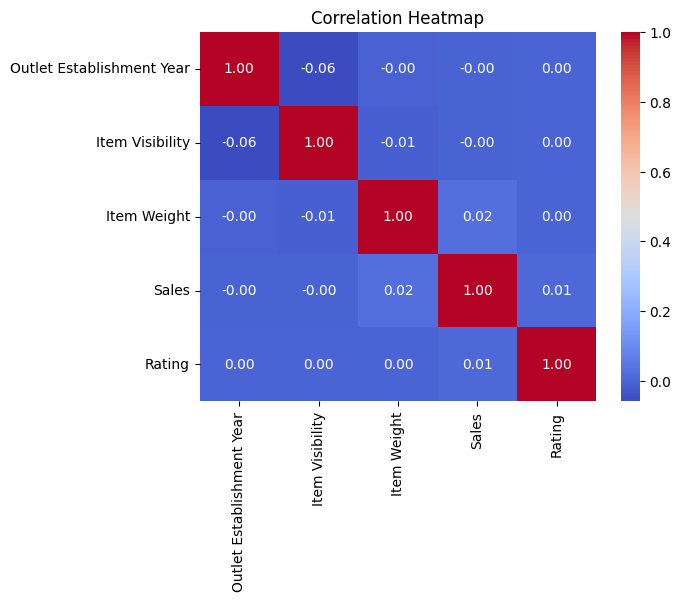

In [17]:
numeric_df = df.select_dtypes(include=('int64', 'float64'))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.savefig('Correlation Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Save Processed dataset

In [24]:
df.to_csv(
    'blinkit_analysis_ready.csv',
    index=False)

### Key Insights

1. Fruits & Vegetables generated the highest sales among all product categories.
2. Snack Foods were the second-largest contributor to revenue.
3. Medium-sized outlets generated the highest sales.
4. Tier 3 locations outperformed other outlet locations.
5. Supermarket Type 1 contributed the highest overall sales.
6. Product ratings showed minimal impact on sales.
7. Item visibility exhibited only a weak relationship with sales.

### Business Recommendations

1. Increase inventory allocation for Fruits & Vegetables and Snack Foods.
2. Expand operations in Tier 3 locations where demand is strongest.
3. Focus investment on high-performing outlet formats.
4. Improve shelf placement for low-performing categories.
5. Use sales performance rather than customer ratings alone for inventory decisions.

### Conclusion

The analysis identified the key factors influencing sales performance across outlet types, outlet sizes, product categories, and locations. Fruits & Vegetables and Snack Foods emerged as the leading revenue-generating categories, while Tier 3 locations and medium-sized outlets demonstrated strong business potential. The findings can support inventory optimization, outlet expansion strategies, and targeted marketing efforts.